# Sentetik Halı Görüntüsü ve Kenar Tespiti Karşılaştırması (Day 12)
Bu çalışma defteri, Merinos geleneksel jakarlı oryantal halı deseni üzerinde birinci ve ikinci derece gradyan operatörleri (Sobel, Scharr, Laplacian) ve Canny optimal kenar tespit algoritmasını karşılaştırmaktadır.

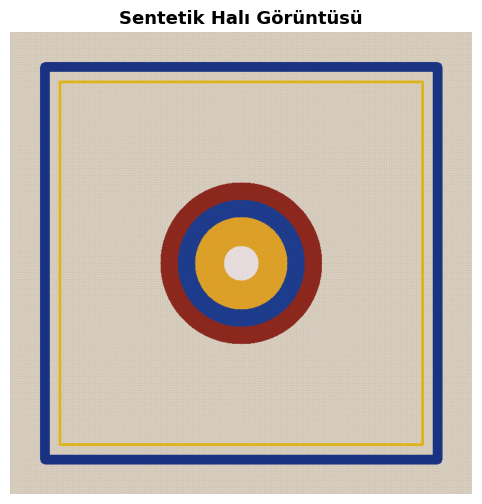

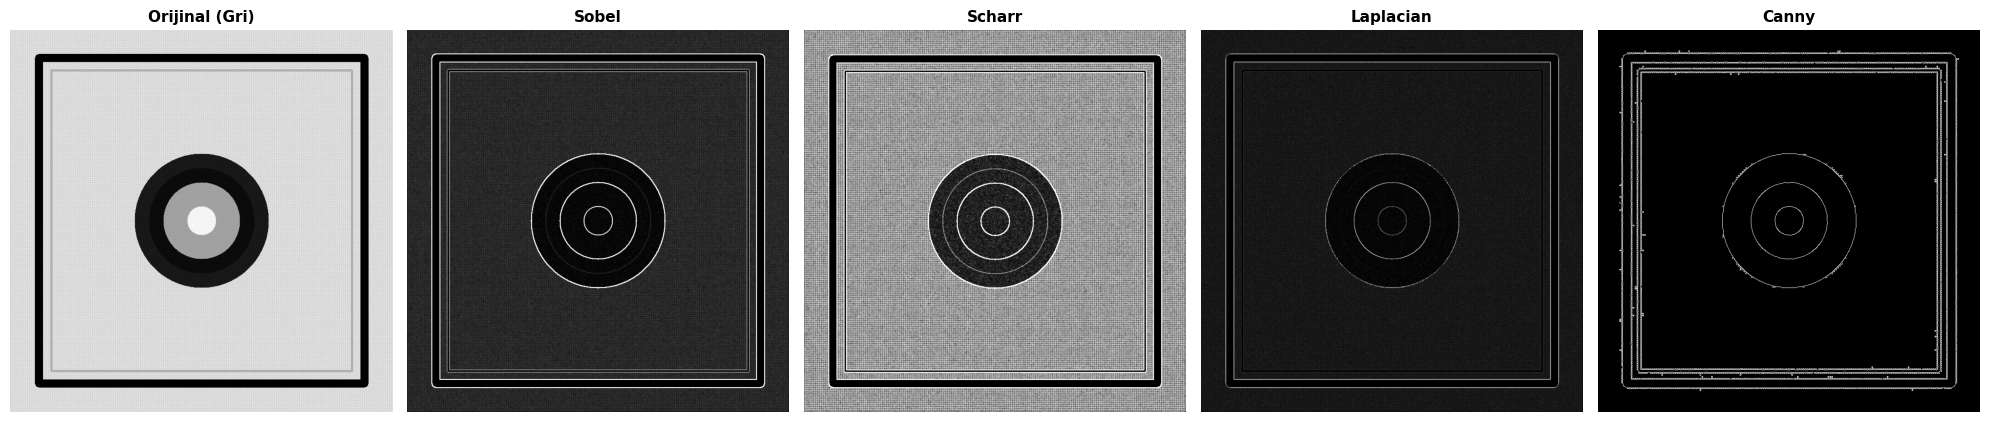

In [1]:
import sys
from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt

CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = CURRENT_DIR.parent.parent if CURRENT_DIR.name == "notebooks" else (CURRENT_DIR.parent if CURRENT_DIR.name == "day12" else CURRENT_DIR)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from day12.mini_project.src.edge_operators import (
    compute_sobel,
    compute_scharr,
    compute_laplacian,
    compute_canny,
)
from day12.mini_project.src.generator import CarpetBorderFixtureGenerator

generator = CarpetBorderFixtureGenerator(seed=42)
fixtures_dir = PROJECT_ROOT / "day12" / "mini_project" / "fixtures" / "synthetic_carpets"
clean_path = fixtures_dir / "carpet_border_clean_parallel.png"

if clean_path.exists():
    raw_data = np.fromfile(str(clean_path), dtype=np.uint8)
    carpet = cv2.imdecode(raw_data, cv2.IMREAD_COLOR)
else:
    carpet = generator.generate_clean_parallel_carpet(width=800, height=600)

# 1. Renkli Sentetik Halı Görüntüsü
plt.figure(figsize=(9, 6))
plt.imshow(cv2.cvtColor(carpet, cv2.COLOR_BGR2RGB))
plt.title("Sentetik Halı Görüntüsü", fontsize=13, fontweight="bold")
plt.axis("off")
plt.show()

# 2. Kenar Operatörlerinin Hesaplanması
gray = cv2.cvtColor(carpet, cv2.COLOR_BGR2GRAY)
sobel_edge = compute_sobel(carpet)
scharr_edge = compute_scharr(carpet)
laplacian_edge = compute_laplacian(carpet)
canny_edge = compute_canny(carpet, low_threshold=50, high_threshold=150)

# 3. Şekil 23 Karşılaştırma Paneli (5'li Alt Izgara)
fig, axes = plt.subplots(1, 5, figsize=(20, 5))
titles = ["Orijinal (Gri)", "Sobel", "Scharr", "Laplacian", "Canny"]
images = [gray, sobel_edge, scharr_edge, laplacian_edge, canny_edge]

for ax, t, im in zip(axes, titles, images):
    ax.imshow(im, cmap="gray")
    ax.set_title(t, fontsize=11, fontweight="bold")
    ax.axis("off")

plt.tight_layout()
plt.show()

## 2. Kenar Operatörleri Karşılaştırma Analizi
| Operatör | Türev Derecesi | Filtre Çekirdeği | Avantajı | Endüstriyel Değerlendirme |
| :--- | :--- | :--- | :--- | :--- |
| **Sobel** | 1. Derece | $3 \times 3$ ayrık türev | Hızlı, yönlü gradyan açısı verir | Bordür kenarlarında kalın çizgi üretir |
| **Scharr** | 1. Derece | $3 \times 3$ optimize | Yüksek rotasyonel izotropi, açısal kararlılık | Çapraz jakar motiflerinde daha hassas |
| **Laplacian** | 2. Derece | $\nabla^2 I$ türevi | Sıfır geçişi ile ince kenar konumu | Gürültüye karşı çok hassastır |
| **Canny** | Çok Aşamalı | Gauss + NMS + Hysteresis | 1 piksel kalınlığında temiz kenar çizgileri | Hough dönüşümü ve bordür analizi için en ideali |